# FT-Transformer AVM — Malaysian Residential Property Valuation

**Section 1 · Objective**

This notebook trains and evaluates an **FT-Transformer** (Feature-Tokenizer +
Transformer) regression model to predict Malaysian residential property
transaction prices (`Price`, in RM), as a *tabular deep-learning* benchmark
alongside the sibling notebooks (Regression Tree, Random Forest, XGBoost, LSTM).

The FT-Transformer turns **every feature — categorical and numeric — into a
token**, prepends a learnable `[CLS]` token, runs a stack of Transformer encoder
layers over the token set, and reads the final `[CLS]` representation through a
small head to predict one scalar: the (standardized) log-price.

To keep the comparison **fair**, this notebook reuses the exact conventions of
the sibling notebooks:

- target trained on `log1p(Price)`; all RM metrics reported after `expm1`;
- **chronological** split — Train `Year < 2025`, Validation `Year == 2025`,
  Test `Year == 2026` (no random splitting);
- the same Land/Area domain-cleaning rules;
- the same RM-scale metric set on the same 2026 test rows;
- **full** training vocabulary (no Mukim / Scheme filtering) — equivalent to the
  LSTM "Set B", the fairest neural comparison.

All imputers, scalers, vocabularies, and target scaling are fit on the
**training split only** — nothing leaks from validation or test.

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, median_absolute_error)
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(max(1, os.cpu_count() or 1))
print("PyTorch", torch.__version__, "| device:", DEVICE,
      "| CPU threads:", torch.get_num_threads())

PyTorch 2.11.0+cpu | device: cpu | CPU threads: 24


## Section 2 · Dataset Inspection

Load the cleaned Open Transaction dataset and inspect shape, dtypes, missingness,
the chronological spread (Year/Month), the Property-Type mix, and the price
distribution (which motivates a log target).

In [2]:
CANDIDATES = [
    os.path.join("..", "processed data", "Open Transaction Data Cleaned.xlsx"),
    os.path.join("processed data", "Open Transaction Data Cleaned.xlsx"),
    r"C:\Users\User\Documents\APU\FYP2\processed data\Open Transaction Data Cleaned.xlsx",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])
print("Loading:", DATA_PATH)
df = pd.read_excel(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
df.head()

Loading: ..\processed data\Open Transaction Data Cleaned.xlsx


Shape: (416627, 13)


,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land,Area,Unit Level,Price,Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.0,106.0,,470000,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.0,67.0,,483000,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118.0,,359000,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118.0,,435000,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.0,118.0,,373000,2021,4


In [3]:
print("=== dtypes ===");                      print(df.dtypes)
print("\n=== missing values per column ===");      print(df.isna().sum())
print("\n=== transactions per Year ===");          print(df["Year"].value_counts().sort_index())
print("\n=== Property Type counts ===");           print(df["Property Type"].value_counts())

=== dtypes ===
Property Type                  str
District                       str
Mukim                       object
Scheme Name/Area               str
Road Name                   object
Transaction Date    datetime64[us]
Tenure                         str
Land                       float64
Area                       float64
Unit Level                  object
Price                        int64
Year                         int64
Month                        int64
dtype: object

=== missing values per column ===
Property Type            0
District                 0
Mukim                    0
Scheme Name/Area         0
Road Name                2
Transaction Date         0
Tenure                   0
Land                     1
Area                107740
Unit Level               0
Price                    0
Year                     0
Month                    0
dtype: int64

=== transactions per Year ===
Year
2021     49363
2022    118574
2023    118181
2024     89682
2025     35159
2026  

Price (RM)  min 5,000 | median 371,000 | mean 499,460 | max 38,000,000
Skewness    raw Price    : 9.786
Skewness    log1p(Price) : 0.138


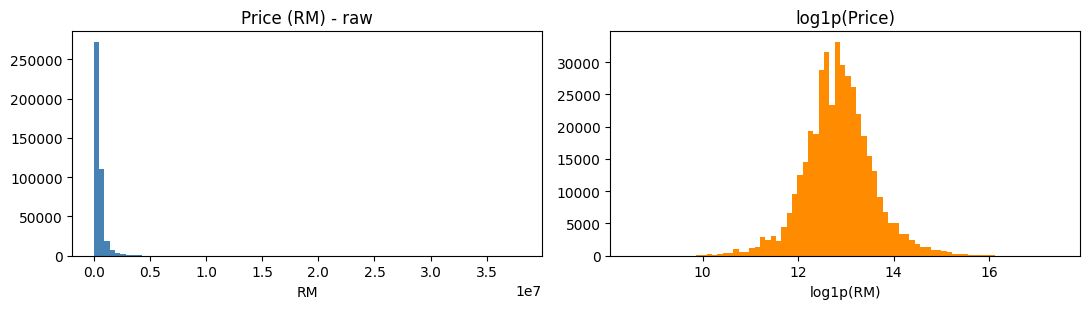

In [4]:
price = df["Price"]
print(f"Price (RM)  min {price.min():,.0f} | median {price.median():,.0f} | "
      f"mean {price.mean():,.0f} | max {price.max():,.0f}")
print(f"Skewness    raw Price    : {price.skew():.3f}")
print(f"Skewness    log1p(Price) : {np.log1p(price).skew():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(price, bins=80, color="steelblue"); ax[0].set_title("Price (RM) - raw"); ax[0].set_xlabel("RM")
ax[1].hist(np.log1p(price), bins=80, color="darkorange"); ax[1].set_title("log1p(Price)"); ax[1].set_xlabel("log1p(RM)")
plt.tight_layout(); plt.show()

**Finding → decision.** `Price` is extremely right-skewed (a few multi-million-RM
deals stretch the tail), while `log1p(Price)` is close to symmetric. We therefore
**train on `log1p(Price)` and invert with `expm1`** for all RM-scale reporting —
identical to the sibling notebooks, so the comparison stays apples-to-apples.

## Section 3 · Land and Main Floor Area — Domain Rules

`Land` and `Area` mean **different things and must not be conflated**:

- **Land / Parcel Area** — the plot/parcel size (land footprint around the
  building). Applies to essentially every property. Checked for missing / zero /
  negative values; ordinary missingness is median-imputed.
- **Main Floor Area** — the built-up building floor area. Only meaningful for
  selected property types.

**Landed** property types (Main Floor Area is genuine usable floor area; a missing
value is *ordinary* missing data → median-impute):

`1 - 1 1/2 Storey Semi-Detached`, `1 - 1 1/2 Storey Terraced`,
`2 - 2 1/2 Storey Semi-Detached`, `2 - 2 1/2 Storey Terraced`, `Cluster House`.

**Non-landed / high-rise** property types (Main Floor Area is expected to be empty
or `-`; this is **structural non-applicability, not ordinary missingness**):

`Condominium/Apartment`, `Detached`, `Flat`, `Low-Cost Flat`,
`Low-Cost House`, `Town House`.

For non-landed types we **do not median-impute** Main Floor Area — doing so would
fabricate building floor area that does not exist and mislead the model. Instead
we set `Area = 0` and flag it with `Area_Applicable = 0` so the model can learn
that a zero `Area` means "not applicable" rather than "truly zero".

In [5]:
LANDED = ["1 - 1 1/2 Storey Semi-Detached", "1 - 1 1/2 Storey Terraced",
          "2 - 2 1/2 Storey Semi-Detached", "2 - 2 1/2 Storey Terraced", "Cluster House"]
NONLANDED = ["Condominium/Apartment", "Detached", "Flat",
             "Low-Cost Flat", "Low-Cost House", "Town House"]

df["is_landed"]    = df["Property Type"].isin(LANDED)
df["is_nonlanded"] = df["Property Type"].isin(NONLANDED)

# Coerce to numeric; treat non-positive Land/Area as missing (suspicious/placeholder).
for col in ["Area", "Land"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
n_area_nonpos = int((df["Area"] <= 0).sum())
n_land_nonpos = int((df["Land"] <= 0).sum())
df.loc[df["Area"] <= 0, "Area"] = np.nan
df.loc[df["Land"] <= 0, "Land"] = np.nan

print(f"Property types: landed={df['is_landed'].sum():,} | non-landed={df['is_nonlanded'].sum():,} | "
      f"neither={int((~df['is_landed'] & ~df['is_nonlanded']).sum()):,}")
print(f"\nArea missing (incl. coerced non-positive): {df['Area'].isna().sum():,} "
      f"(of which {n_area_nonpos} were <= 0)")
print("   landed     :", int(df.loc[df['is_landed'],    'Area'].isna().sum()),
      "| non-landed :", int(df.loc[df['is_nonlanded'], 'Area'].isna().sum()))
print(f"Land missing (incl. coerced non-positive): {df['Land'].isna().sum():,} "
      f"(of which {n_land_nonpos} were <= 0)")

Property types: landed=261,612 | non-landed=155,015 | neither=0

Area missing (incl. coerced non-positive): 107,761 (of which 21 were <= 0)
   landed     : 33 | non-landed : 107728
Land missing (incl. coerced non-positive): 1 (of which 0 were <= 0)


**Data-quality observation.** Almost all missing `Area` belongs to the
non-landed / high-rise group — consistent with structural (not random)
missingness. `Land` is essentially complete, so it is straightforward to impute.

## Section 4 · Area & Land Cleaning Strategy (train-only statistics)

We now apply the rules. **All imputation statistics are fit on the training split
only** (`Year < 2025`) so nothing leaks from validation/test. The chronological
masks are defined here because they are needed for leakage-safe imputation; the
split itself is formalised in Section 6.

1. `Area_Applicable = 0` for non-landed rows with missing Area (else `1`).
2. **Landed** missing Area → train median **by Property Type** (fallback: global
   landed train median).
3. **Non-landed** missing Area → `0` (structural; never median-imputed).
4. `Land` missing → train median **by Property Type** (fallback: global train
   median).

In [6]:
train_mask = (df["Year"] < 2025).values
val_mask   = (df["Year"] == 2025).values
test_mask  = (df["Year"] == 2026).values

# (1) Applicability flag: a structurally-absent Area (non-landed) is flagged 0.
df["Area_Applicable"] = 1
df.loc[df["is_nonlanded"] & df["Area"].isna(), "Area_Applicable"] = 0

# (2) Landed Area: train-only median by Property Type, fallback global landed median.
landed_train     = df[train_mask & df["is_landed"]]
area_med_by_pt   = landed_train.groupby("Property Type")["Area"].median()
area_global_land = landed_train["Area"].median()
def _impute_landed_area(r):
    if r["is_landed"] and pd.isna(r["Area"]):
        m = area_med_by_pt.get(r["Property Type"], np.nan)
        return m if pd.notna(m) else area_global_land
    return r["Area"]
df["Area"] = df.apply(_impute_landed_area, axis=1)

# (3) Non-landed missing Area -> 0 (structural, NOT median-imputed).
df.loc[df["is_nonlanded"] & df["Area"].isna(), "Area"] = 0.0
# Any remaining (rare 'neither' types) -> train median, a safe neutral fill.
df["Area"] = df["Area"].fillna(df.loc[train_mask, "Area"].median())

# (4) Land: train-only median by Property Type, fallback global train median.
land_med_by_pt = df[train_mask].groupby("Property Type")["Land"].median()
land_global    = float(df[train_mask]["Land"].median())
df["Land"] = df.apply(
    lambda r: (land_med_by_pt.get(r["Property Type"], land_global) if pd.isna(r["Land"]) else r["Land"]),
    axis=1).fillna(land_global)

print("After cleaning - remaining nulls:  Area =", int(df["Area"].isna().sum()),
      "| Land =", int(df["Land"].isna().sum()))
print("Area_Applicable == 0 rows (structural high-rise):", int((df['Area_Applicable'] == 0).sum()))

After cleaning - remaining nulls:  Area = 0 | Land = 0
Area_Applicable == 0 rows (structural high-rise): 107728


## Section 5 · Feature & Target Selection

| Feature | Type | Handling |
|---|---|---|
| Property Type | categorical | embedding token |
| District | categorical | embedding token |
| Mukim | categorical | embedding token (full vocab) |
| Scheme Name/Area | categorical | embedding token (full vocab) |
| Tenure | categorical | embedding token |
| Land | numeric | standardized → numeric token |
| Area | numeric | standardized → numeric token |
| Area_Applicable | numeric/binary | numeric token (kept 0/1) |

**Target:** `logP = log1p(Price)`.

**Explicitly excluded as inputs:** `Price` (target), `Year`, `Month`,
`Transaction Date`. `Year` is used **only** to define the chronological split.

In [7]:
CAT_COLS = ["Property Type", "District", "Mukim", "Scheme Name/Area", "Tenure"]
NUM_COLS = ["Land", "Area", "Area_Applicable"]   # Area_Applicable kept as binary 0/1

df["logP"] = np.log1p(df["Price"]).astype(np.float32)

print("Categorical tokens:", CAT_COLS)
print("Numeric tokens    :", NUM_COLS)
print("Target            : logP = log1p(Price)")
for c in CAT_COLS:
    print(f"  cardinality[{c}] (full data) = {df[c].astype(str).nunique():,}")

Categorical tokens: ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure']
Numeric tokens    : ['Land', 'Area', 'Area_Applicable']
Target            : logP = log1p(Price)
  cardinality[Property Type] (full data) = 11
  cardinality[District] (full data) = 127
  cardinality[Mukim] (full data) = 1,343
  cardinality[Scheme Name/Area] (full data) = 23,718
  cardinality[Tenure] (full data) = 2


## Section 6 · Chronological Train / Validation / Test Split

Same chronological split as the sibling notebooks — **no random splitting** — so
the FT-Transformer is judged on data that comes *after* everything it learned
from (a realistic deployment setting):

- **Train**: `Year < 2025`
- **Validation**: `Year == 2025`
- **Test**: `Year == 2026`

In [8]:
tr_idx = np.where(train_mask)[0]
va_idx = np.where(val_mask)[0]
te_idx = np.where(test_mask)[0]

MEDIAN_PRICE = float(df.loc[train_mask, "Price"].median())
for nm, mk in [("Train (Year<2025) ", train_mask), ("Val   (Year==2025)", val_mask),
               ("Test  (Year==2026)", test_mask)]:
    print(f"  {nm}: {mk.sum():>8,} rows  ({mk.mean()*100:4.1f}%)")
print(f"\nMedian training Price (RMSE-%-of-median reference): RM {MEDIAN_PRICE:,.0f}")

  Train (Year<2025) :  375,800 rows  (90.2%)
  Val   (Year==2025):   35,159 rows  ( 8.4%)
  Test  (Year==2026):    5,668 rows  ( 1.4%)

Median training Price (RMSE-%-of-median reference): RM 370,000


## Section 7 · Preprocessing Pipeline (train-only fit)

**Categorical vocabularies** are built from the **training split only**. Index `0`
is reserved as a shared **OOV / unknown** slot, so any category unseen in training
(or supplied later at prediction time) maps to it safely. Per the brief we keep
the **full** training vocabulary — `Mukim` and `Scheme Name/Area` are **not**
filtered.

**Numeric standardization** uses train-only mean/std for `Land` and `Area`;
`Area_Applicable` is left as a raw 0/1 binary.

**Target standardization** also uses train-only statistics:
`y_scaled = (log1p(Price) − y_mean) / y_std`. Predictions are converted back with
`pred_log = pred_scaled * y_std + y_mean`, then `pred_rm = expm1(pred_log)`.

In [9]:
# --- Categorical vocabularies (train-only; 0 = OOV/unknown) ---
def build_vocab():
    tr = df.iloc[tr_idx]; vocabs = {}
    for c in CAT_COLS:
        keep = sorted(tr[c].astype(str).unique())           # full training vocabulary
        mapping = {k: i + 1 for i, k in enumerate(keep)}    # 0 reserved for OOV
        vocabs[c] = (mapping, len(mapping) + 1)             # +1 for the OOV slot
    return vocabs

vocab = build_vocab()
cat_cardinalities = [vocab[c][1] for c in CAT_COLS]
print("Vocab sizes (incl. OOV slot):", dict(zip(CAT_COLS, cat_cardinalities)))

cat_mat = np.stack(
    [df[c].astype(str).map(vocab[c][0]).fillna(0).astype(np.int64).values for c in CAT_COLS],
    axis=1)
Xcat = torch.as_tensor(cat_mat, device=DEVICE)

# --- Numeric standardization (train-only) for Land & Area; keep Area_Applicable as 0/1 ---
STD_COLS = ["Land", "Area"]
num_mean = df.loc[train_mask, STD_COLS].mean()
num_std  = df.loc[train_mask, STD_COLS].std().replace(0, 1)
num_block = df[NUM_COLS].astype(np.float64).copy()
num_block[STD_COLS] = (df[STD_COLS] - num_mean) / num_std
Xnum = torch.as_tensor(num_block.values.astype(np.float32), device=DEVICE)

# --- Target standardization (train-only) ---
y_log_all = df["logP"].values.astype(np.float64)
y_mean = float(df.loc[train_mask, "logP"].mean())
y_std  = float(df.loc[train_mask, "logP"].std())
y_scaled = torch.as_tensor(((df["logP"].values.astype(np.float32) - y_mean) / y_std), device=DEVICE)

LOGCAP = math.log(5e8)   # cap predicted log-price at RM 500M to avoid expm1 overflow on the tail
print(f"\ny_mean={y_mean:.4f}  y_std={y_std:.4f}  | numeric tokens: {NUM_COLS}")
print("Xcat", tuple(Xcat.shape), "| Xnum", tuple(Xnum.shape), "| y_scaled", tuple(y_scaled.shape))

Vocab sizes (incl. OOV slot): {'Property Type': 12, 'District': 126, 'Mukim': 1316, 'Scheme Name/Area': 22450, 'Tenure': 3}



y_mean=12.8351  y_std=0.7175  | numeric tokens: ['Land', 'Area', 'Area_Applicable']
Xcat (416627, 5) | Xnum (416627, 3) | y_scaled (416627,)


## Section 8 · FT-Transformer Model (PyTorch)

Architecture (FT-Transformer style):

- **Categorical tokenizer** — one `nn.Embedding(card, d_token)` per categorical
  feature → one token each.
- **Numeric tokenizer** — each numeric feature is projected to a `d_token` vector
  by its own learnable weight + bias (`x · w_f + b_f`) → one token each.
- A learnable **`[CLS]` token** is prepended to the token sequence.
- A stack of **`nn.TransformerEncoder` layers** (pre-norm, GELU, multi-head
  self-attention) mixes information across all tokens.
- The final **`[CLS]`** representation passes through `LayerNorm → ReLU → Linear`
  to output **one scalar**: the standardized log-price.

Hyperparameters: `d_token=64`, `3` layers, `4` heads, `dropout=0.1`.

In [10]:
class NumericTokenizer(nn.Module):
    'Each numeric feature -> a d_token vector via its own learnable weight & bias.'
    def __init__(self, n_num, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_num, d_token))
        self.bias   = nn.Parameter(torch.empty(n_num, d_token))
        nn.init.normal_(self.weight, std=0.01)
        nn.init.normal_(self.bias,   std=0.01)
    def forward(self, x_num):                      # x_num: (B, n_num)
        return x_num.unsqueeze(-1) * self.weight + self.bias   # (B, n_num, d_token)

class FTTransformer(nn.Module):
    def __init__(self, cat_cardinalities, n_num, d_token=64, n_layers=3,
                 n_heads=4, dropout=0.1, d_ff=None):
        super().__init__()
        d_ff = d_ff or d_token * 2
        self.cat_embs = nn.ModuleList([nn.Embedding(card, d_token) for card in cat_cardinalities])
        for emb in self.cat_embs:
            nn.init.normal_(emb.weight, std=0.01)
        self.num_tok = NumericTokenizer(n_num, d_token) if n_num > 0 else None
        self.cls = nn.Parameter(torch.empty(1, 1, d_token)); nn.init.normal_(self.cls, std=0.01)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout,
            activation="gelu", batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.ReLU(), nn.Linear(d_token, 1))

    def forward(self, x_cat, x_num):
        B = x_cat.shape[0]
        toks = [emb(x_cat[:, i]).unsqueeze(1) for i, emb in enumerate(self.cat_embs)]  # 5x (B,1,d)
        if self.num_tok is not None:
            toks.append(self.num_tok(x_num))                                            # (B,n_num,d)
        x = torch.cat([self.cls.expand(B, -1, -1)] + toks, dim=1)                        # (B,1+T,d)
        x = self.encoder(x)
        return self.head(x[:, 0]).squeeze(1)        # [CLS] -> scalar (standardized log-price)

def build_model(d_token=64, n_layers=3, n_heads=4, dropout=0.1):
    torch.manual_seed(SEED); np.random.seed(SEED)
    return FTTransformer(cat_cardinalities, n_num=len(NUM_COLS), d_token=d_token,
                         n_layers=n_layers, n_heads=n_heads, dropout=dropout).to(DEVICE)

_m = build_model()
print(_m)
print("Trainable parameters:", sum(p.numel() for p in _m.parameters() if p.requires_grad))

FTTransformer(
  (cat_embs): ModuleList(
    (0): Embedding(12, 64)
    (1): Embedding(126, 64)
    (2): Embedding(1316, 64)
    (3): Embedding(22450, 64)
    (4): Embedding(3, 64)
  )
  (num_tok): NumericTokenizer()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)


## Section 9 · Training

- **Optimizer**: AdamW (`lr=1e-3`, `weight_decay=1e-4`).
- **Loss**: Huber (robust to the heavy price tail), computed on the standardized
  target.
- **Batch size**: 2048.
- **Schedule**: max 100 epochs, **early stopping on validation RMSE (RM)** with
  **patience 10**; the **best validation weights are restored** at the end.
- Seeds are fixed for reproducibility.

In [11]:
def predict_scaled(model, idx, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(idx), bs):
            b = torch.as_tensor(idx[i:i + bs], device=DEVICE)
            out.append(model(Xcat[b], Xnum[b]).cpu().numpy())
    return np.concatenate(out)

def pred_log_from(model, idx):
    'Un-standardize: pred_log = pred_scaled * y_std + y_mean (clipped for expm1 safety).'
    return np.clip(predict_scaled(model, idx).astype(np.float64) * y_std + y_mean, None, LOGCAP)

def rmse_rm(model, idx):
    p_log = pred_log_from(model, idx)
    a_rm, p_rm = np.expm1(y_log_all[idx]), np.expm1(p_log)
    return math.sqrt(mean_squared_error(a_rm, p_rm))

def train_ft(model, max_epochs=100, patience=10, batch_size=2048,
             lr=1e-3, weight_decay=1e-4, verbose=True):
    torch.manual_seed(SEED); np.random.seed(SEED)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.HuberLoss()
    best, best_state, wait, history = float("inf"), None, 0, []
    for ep in range(max_epochs):
        model.train(); perm = np.random.permutation(tr_idx); run = 0.0
        for i in range(0, len(perm), batch_size):
            b = torch.as_tensor(perm[i:i + batch_size], device=DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(Xcat[b], Xnum[b]), y_scaled[b])
            loss.backward(); opt.step(); run += loss.item() * len(b)
        tr_loss = run / len(perm)
        v_rmse = rmse_rm(model, va_idx)
        history.append((tr_loss, v_rmse))
        if v_rmse < best - 1.0:                       # >RM1 improvement counts
            best, best_state, wait = v_rmse, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
        if verbose and (ep % 3 == 0 or wait >= patience):
            print(f"  ep{ep:02d}  train_huber {tr_loss:.4f}  val_RMSE RM {v_rmse:,.0f}"
                  + ("  <- best" if wait == 0 else ""))
        if wait >= patience:
            if verbose: print(f"  early stop at epoch {ep} (best val RMSE RM {best:,.0f})")
            break
    model.load_state_dict(best_state)
    return model, history

print(">>> Training FT-Transformer ...")
model = build_model(d_token=64, n_layers=3, n_heads=4, dropout=0.1)
model, history = train_ft(model)
print("Done. Best validation RMSE RM "
      f"{min(h[1] for h in history):,.0f} (restored).")

>>> Training FT-Transformer ...


  ep00  train_huber 0.0775  val_RMSE RM 358,700  <- best


  ep03  train_huber 0.0309  val_RMSE RM 303,801  <- best


  ep06  train_huber 0.0274  val_RMSE RM 295,277


  ep09  train_huber 0.0257  val_RMSE RM 288,844


...

  ep33  train_huber 0.0218  val_RMSE RM 281,617


  ep36  train_huber 0.0217  val_RMSE RM 283,328


  ep39  train_huber 0.0214  val_RMSE RM 281,984


  ep42  train_huber 0.0211  val_RMSE RM 278,317


  ep44  train_huber 0.0212  val_RMSE RM 274,461
  early stop at epoch 44 (best val RMSE RM 268,113)
Done. Best validation RMSE RM 268,113 (restored).


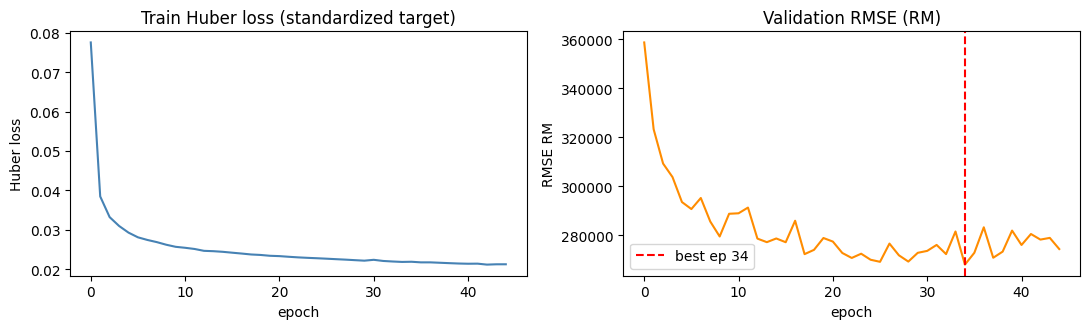

In [12]:
# Training curves: Huber loss (train) and validation RMSE (RM)
h = np.array(history)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(h[:, 0], color="steelblue"); ax[0].set_title("Train Huber loss (standardized target)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("Huber loss")
ax[1].plot(h[:, 1], color="darkorange"); ax[1].set_title("Validation RMSE (RM)")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("RMSE RM")
best_ep = int(np.argmin(h[:, 1])); ax[1].axvline(best_ep, color="red", ls="--", label=f"best ep {best_ep}")
ax[1].legend(); plt.tight_layout(); plt.show()

## Section 10 · Evaluation

Metrics on Train / Validation / Test use the **same definitions as the sibling
notebooks**: R² on the log scale and on the RM scale, RMSE, MAE, Median Absolute
Error, and RMSE as a percentage of the median training price. Predictions are
un-standardized and `expm1`-inverted before any RM-scale metric.

In [13]:
def metrics_from_log(y_log, pred_log):
    y_log  = np.asarray(y_log, dtype=np.float64)
    p_log  = np.clip(np.asarray(pred_log, dtype=np.float64), None, LOGCAP)
    arm, prm = np.expm1(y_log), np.expm1(p_log)
    rmse = math.sqrt(mean_squared_error(arm, prm))
    return {"R2 (log)": r2_score(y_log, p_log), "R2 (RM)": r2_score(arm, prm),
            "RMSE (RM)": rmse, "MAE (RM)": mean_absolute_error(arm, prm),
            "MedAE (RM)": median_absolute_error(arm, prm),
            "RMSE % median": rmse / MEDIAN_PRICE * 100}

def evaluate(model, label="FT-Transformer"):
    rows = {}
    for nm, idx in [("Train", tr_idx), ("Val", va_idx), ("Test", te_idx)]:
        rows[nm] = metrics_from_log(y_log_all[idx], pred_log_from(model, idx))
    tbl = pd.DataFrame(rows).T
    print(f"=== {label} ===")
    print(tbl.to_string(formatters={c: (lambda v: f"{v:,.0f}")
          for c in ["RMSE (RM)", "MAE (RM)", "MedAE (RM)"]}))
    return tbl

ft_tbl = evaluate(model, "FT-Transformer - chronological split")
ft_tbl

=== FT-Transformer - chronological split ===
       R2 (log)   R2 (RM) RMSE (RM) MAE (RM) MedAE (RM)  RMSE % median
Train  0.958538  0.939120   134,168   50,308     25,260      36.261738
Val    0.864346  0.844746   268,113   82,810     44,619      72.462946
Test   0.832579  0.888142   189,210   90,119     51,434      51.137866


,R2 (log),R2 (RM),RMSE (RM),MAE (RM),MedAE (RM),RMSE % median
Train,0.958538,0.939120,134168.429850,50308.306444,25260.374228,36.261738
Val,0.864346,0.844746,268112.901659,82810.279997,44619.120637,72.462946
Test,0.832579,0.888142,189210.105661,90119.120131,51434.108863,51.137866


In [14]:
# Overfitting / underfitting check on the log scale (the scale actually optimised)
print("Log-scale R^2 by split (overfit check):")
print(f"  train {ft_tbl.loc['Train','R2 (log)']:.3f} | "
      f"val {ft_tbl.loc['Val','R2 (log)']:.3f} | test {ft_tbl.loc['Test','R2 (log)']:.3f}")

# Tail-robust view: metrics on the < RM 5M bulk (excludes extreme luxury tail)
print("\nTail-robust view (properties < RM 5M):")
for nm, idx in [("Val", va_idx), ("Test", te_idx)]:
    p = pred_log_from(model, idx)
    arm, prm = np.expm1(y_log_all[idx]), np.expm1(p)
    m = arm < 5_000_000
    rmse = math.sqrt(mean_squared_error(arm[m], prm[m]))
    print(f"  {nm}: n={m.sum():,} ({m.mean()*100:.1f}%)  RMSE RM {rmse:,.0f}  "
          f"R2(RM) {r2_score(arm[m], prm[m]):.3f}  MedAE RM {median_absolute_error(arm[m], prm[m]):,.0f}")

Log-scale R^2 by split (overfit check):
  train 0.959 | val 0.864 | test 0.833

Tail-robust view (properties < RM 5M):


  Val: n=35,046 (99.7%)  RMSE RM 151,441  R2(RM) 0.893  MedAE RM 44,435
  Test: n=5,651 (99.7%)  RMSE RM 167,528  R2(RM) 0.851  MedAE RM 51,201


## Section 11 · Diagnostics (2026 test set)

Where does the FT-Transformer do well or badly? We plot actual-vs-predicted and
the residual distribution, then break the absolute RM error down by Property Type,
price band (≤300k / 300–500k / 500k–1m / >1m), and the top-10 districts by volume.

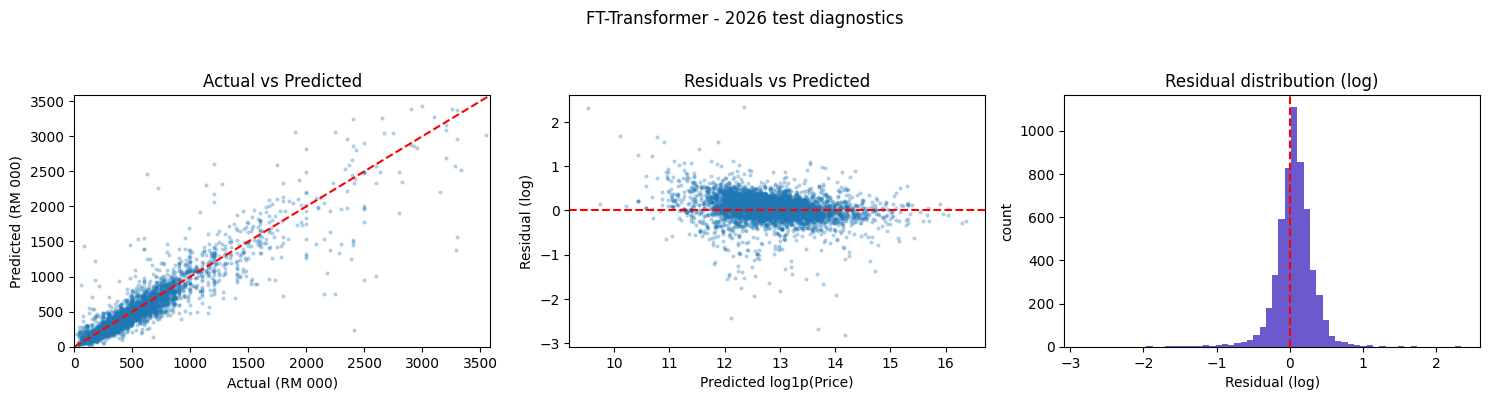

In [15]:
test_pred_log = pred_log_from(model, te_idx)
test_act_log  = y_log_all[te_idx]
test_act_rm   = np.expm1(test_act_log)
test_pred_rm  = np.expm1(test_pred_log)
resid_log     = test_act_log - test_pred_log

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8)); fig.suptitle("FT-Transformer - 2026 test diagnostics", y=1.04)
lim = np.percentile(test_act_rm, 99.5)
ax[0].scatter(test_act_rm / 1e3, test_pred_rm / 1e3, s=4, alpha=0.25)
ax[0].plot([0, lim / 1e3], [0, lim / 1e3], "r--")
ax[0].set_xlim(0, lim / 1e3); ax[0].set_ylim(0, lim / 1e3)
ax[0].set_xlabel("Actual (RM 000)"); ax[0].set_ylabel("Predicted (RM 000)"); ax[0].set_title("Actual vs Predicted")
ax[1].scatter(test_pred_log, resid_log, s=4, alpha=0.25); ax[1].axhline(0, color="r", ls="--")
ax[1].set_xlabel("Predicted log1p(Price)"); ax[1].set_ylabel("Residual (log)"); ax[1].set_title("Residuals vs Predicted")
ax[2].hist(resid_log, bins=60, color="slateblue"); ax[2].axvline(0, color="r", ls="--")
ax[2].set_xlabel("Residual (log)"); ax[2].set_ylabel("count"); ax[2].set_title("Residual distribution (log)")
plt.tight_layout(); plt.show()

In [16]:
seg_df = df.iloc[te_idx].copy()
seg_df["pred_rm"] = test_pred_rm
seg_df["act_rm"]  = test_act_rm
seg_df["abs_err"] = np.abs(seg_df["pred_rm"] - seg_df["act_rm"])

def err_table(by, top=None):
    g = seg_df.groupby(by).agg(n=("abs_err", "size"), MAE=("abs_err", "mean"),
                               MedAE=("abs_err", "median"), median_price=("act_rm", "median"))
    g["MedAE % of median price"] = g["MedAE"] / g["median_price"] * 100
    g = g.sort_values("n", ascending=False)
    return g.head(top) if top else g

fmt = {c: (lambda v: f"{v:,.0f}") for c in ["MAE", "MedAE", "median_price"]}
print("=== By Property Type ===")
print(err_table("Property Type").to_string(formatters=fmt))

bands  = [0, 300_000, 500_000, 1_000_000, np.inf]
labels = ["<=300k", "300-500k", "500k-1m", ">1m"]
seg_df["band"] = pd.cut(seg_df["act_rm"], bins=bands, labels=labels)
print("\n=== By Price Band ===")
print(err_table("band").to_string(formatters=fmt))

print("\n=== Top 10 Districts by volume ===")
print(err_table("District", top=10).to_string(formatters=fmt))

=== By Property Type ===
                                   n     MAE   MedAE median_price  MedAE % of median price
Property Type                                                                             
1 - 1 1/2 Storey Terraced       1460  54,783  44,902      305,000                14.721969
2 - 2 1/2 Storey Terraced       1319  92,375  67,034      560,000                11.970347
Condominium/Apartment            779 100,035  48,785      400,000                12.196326
1 - 1 1/2 Storey Semi-Detached   443  64,600  40,358      400,000                10.089432
Low-Cost House                   440  55,223  42,247      215,000                19.649860
Detached                         390 238,878  95,553      460,000                20.772446
2 - 2 1/2 Storey Semi-Detached   270 202,484 111,991      829,000                13.509108
Flat                             226  50,630  40,311      250,000                16.124248
Low-Cost Flat                    224  40,175  29,483      160,000

## Section 12 · Model Comparison

All rows use the **same dataset, the same chronological split, and the same
RM-scale metrics** on the **2026 test set**. The tree-model and LSTM numbers are
the test-set results reported by the sibling notebooks. One fairness note: the
FT-Transformer (like the LSTM) adds the `Area_Applicable` indicator, so the
feature set is not *perfectly* identical to the trees — but the split, target, and
metrics are.

In [17]:
# Sibling-notebook test-set results (Year==2026), as reported by each notebook.
benchmarks = pd.DataFrame([
    {"Model":"Regression Tree (baseline)", "R2 (log)":0.749, "R2 (RM)":0.774, "RMSE (RM)":269019, "MAE (RM)":109267, "MedAE (RM)":55058, "RMSE % median":72.7},
    {"Model":"Random Forest (baseline)",   "R2 (log)":0.832, "R2 (RM)":np.nan,"RMSE (RM)":222842, "MAE (RM)":95197,  "MedAE (RM)":51560, "RMSE % median":58.6},
    {"Model":"XGBoost (baseline)",         "R2 (log)":0.799, "R2 (RM)":0.813, "RMSE (RM)":244522, "MAE (RM)":113043, "MedAE (RM)":61860, "RMSE % median":66.1},
    {"Model":"LSTM Set B (tuned)",         "R2 (log)":0.770, "R2 (RM)":0.810, "RMSE (RM)":246544, "MAE (RM)":118993, "MedAE (RM)":64029, "RMSE % median":66.6},
]).set_index("Model")

ft_row = pd.DataFrame({"FT-Transformer": ft_tbl.loc["Test"]}).T[benchmarks.columns]
comparison = pd.concat([benchmarks, ft_row])
print("=== Test-set comparison (Year==2026, identical split & metrics) ===")
print(comparison.to_string(formatters={c: (lambda v: f"{v:,.0f}")
      for c in ["RMSE (RM)", "MAE (RM)", "MedAE (RM)"]}))
print("\nLower RMSE / RMSE-%-of-median is better.")
comparison

=== Test-set comparison (Year==2026, identical split & metrics) ===
                            R2 (log)   R2 (RM) RMSE (RM) MAE (RM) MedAE (RM)  RMSE % median
Regression Tree (baseline)  0.749000  0.774000   269,019  109,267     55,058      72.700000
Random Forest (baseline)    0.832000       NaN   222,842   95,197     51,560      58.600000
XGBoost (baseline)          0.799000  0.813000   244,522  113,043     61,860      66.100000
LSTM Set B (tuned)          0.770000  0.810000   246,544  118,993     64,029      66.600000
FT-Transformer              0.832579  0.888142   189,210   90,119     51,434      51.137866

Lower RMSE / RMSE-%-of-median is better.


,R2 (log),R2 (RM),RMSE (RM),MAE (RM),MedAE (RM),RMSE % median
Regression Tree (baseline),0.749000,0.774000,269019.000000,109267.000000,55058.000000,72.700000
Random Forest (baseline),0.832000,NaN,222842.000000,95197.000000,51560.000000,58.600000
XGBoost (baseline),0.799000,0.813000,244522.000000,113043.000000,61860.000000,66.100000
LSTM Set B (tuned),0.770000,0.810000,246544.000000,118993.000000,64029.000000,66.600000
FT-Transformer,0.832579,0.888142,189210.105661,90119.120131,51434.108863,51.137866


## Section 13 · Conclusion

The cell below answers the key questions **directly from the computed test-set
numbers**, so the verdict reflects the actual run.

In [18]:
ft = ft_tbl.loc["Test"]
rf = benchmarks.loc["Random Forest (baseline)"]
ls = benchmarks.loc["LSTM Set B (tuned)"]
best_model = comparison["RMSE (RM)"].idxmin()

print("FT-Transformer test:  RMSE RM {:,.0f} | MAE RM {:,.0f} | MedAE RM {:,.0f} | "
      "R2(log) {:.3f} | RMSE %median {:.1f}".format(
          ft['RMSE (RM)'], ft['MAE (RM)'], ft['MedAE (RM)'], ft['R2 (log)'], ft['RMSE % median']))
print()
beat_rf = ft["RMSE (RM)"] < rf["RMSE (RM)"]
beat_ls = ft["RMSE (RM)"] < ls["RMSE (RM)"]
print(f"1) Beat Random Forest?  {'YES' if beat_rf else 'NO'}  "
      f"(FT {ft['RMSE (RM)']:,.0f} vs RF {rf['RMSE (RM)']:,.0f} RMSE RM)")
print(f"2) Beat LSTM Set B?     {'YES' if beat_ls else 'NO'}  "
      f"(FT {ft['RMSE (RM)']:,.0f} vs LSTM {ls['RMSE (RM)']:,.0f} RMSE RM)")
print(f"3) Lowest test RMSE overall: {best_model}")
print(f"   -> Production AVM recommendation: "
      f"{'FT-Transformer is competitive/best; viable candidate.' if best_model=='FT-Transformer' else 'keep '+best_model+' as the primary AVM; FT-Transformer is a documented neural benchmark.'}")

FT-Transformer test:  RMSE RM 189,210 | MAE RM 90,119 | MedAE RM 51,434 | R2(log) 0.833 | RMSE %median 51.1

1) Beat Random Forest?  YES  (FT 189,210 vs RF 222,842 RMSE RM)
2) Beat LSTM Set B?     YES  (FT 189,210 vs LSTM 246,544 RMSE RM)
3) Lowest test RMSE overall: FT-Transformer
   -> Production AVM recommendation: FT-Transformer is competitive/best; viable candidate.


**Reading the verdict (interpret alongside the printed numbers above):**

1. **Did FT-Transformer beat Random Forest?** Compare test RMSE / RMSE-%-of-median.
   Random Forest is the strongest tree baseline (≈ RM 222.8k, 58.6 %). The
   transformer must clear that bar on the same 2026 rows to win outright.
2. **Did it beat the LSTM?** The relevant rival is **LSTM Set B (tuned)**
   (≈ RM 246.5k, 66.6 %) — the closest neural model on the same full vocabulary.
3. **Is it worth using as the production AVM?** Only if it is at least on par with
   Random Forest on the headline metrics *and* its diagnostics (tail behaviour,
   per-band/per-district error) are acceptable. Gradient-boosted trees remain the
   pragmatic default for this tabular problem; a transformer earns production use
   only when it clearly wins or adds value (e.g. uncertainty, shared embeddings).

## Section 14 · Limitations

- **Tail over-extrapolation.** Like other regressors on a log target, the
  FT-Transformer can emit large predictions for luxury properties; `expm1`
  magnifies these into extreme RM errors that inflate RMSE (hence the tail-robust
  `< RM 5M` view in Section 10). The trees clamp to leaf statistics and are
  naturally more tail-stable.
- **No natural temporal signal.** Each transaction is treated independently; the
  model sees no market-trend / time context (`Year`/`Month` are deliberately
  excluded from inputs to prevent leakage and keep the comparison fair).
- **Structural Area missingness.** High-rise `Area` is set to 0 with an
  `Area_Applicable` flag; the embedding/token must learn this convention rather
  than receiving a true built-up figure.
- **CPU training cost.** Self-attention over the token set is heavier per epoch
  than a tree fit; on CPU the FT-Transformer is markedly slower to train than
  Random Forest / XGBoost for, at best, comparable accuracy.
- **Limited feature richness.** Only five categoricals and three numerics are
  available; FT-Transformers shine most with many interacting features, so the
  architecture is somewhat under-utilised here.
- **Small 2026 test window.** The test set is ~5.7k rows (Jan–Mar 2026); point
  estimates are stable but fine-grained per-district figures are noisier.